<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/MultiphaseOptim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multiphase gathering-network modeling and optimization with NeqSim

This notebook develops a reproducible oil, gas, and water gathering-network study. Two
unequal wellstreams flow through independent subsea branches to a common manifold, then
through a thermally coupled export flowline and riser to a three-phase separator.

**Intended audience:** production, process, pipeline, and flow-assurance engineers;
graduate students; and Python users familiar with basic steady-state simulation.

## Prerequisites and learning objectives

You should understand pressure, temperature, mass flow, pipe diameter, and phase
equilibrium. No private fluid file or local NeqSim checkout is required.

After completing the notebook, you can:

1. build distinct three-phase well fluids with NeqSim's SRK model;
2. configure `Stream` and `PipeBeggsAndBrills` objects for two gathering branches;
3. retrieve pressure, temperature, liquid-holdup, velocity, and flow-regime profiles;
4. solve each branch capacity against a shared manifold-pressure constraint;
5. screen manifold pressure and export diameter without leaking mutable state;
6. compose a network with `Mixer`, export pipe, `ThreePhaseSeparator`, and `ProcessSystem`;
7. verify hydraulic residuals, phase bounds, delivery pressure, and mass balance; and
8. separate a screening optimization from a calibrated field-network model.

## Preservation inventory

The original catalog target contained only its Colab badge, one blank code cell, and a
bare link to a commercial network-simulator brochure. It had no calculation, learning
objective, stored output, or substantive figure. The badge is retained above, and the
historical brochure is retained in the references. There are therefore zero pre-existing
examples and zero pre-existing figures to refresh; all technical content below is new.

## 1. Colab-compatible setup

The setup installs the latest public PyPI release only when `neqsim` is absent. A clean
Colab runtime needs no restart, hidden file, credential, or manually supplied JAR.

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            "neqsim",
        ]
    )

In [2]:
import importlib.metadata
import math
import platform

import jpype
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
import numpy as np
import pandas as pd

from neqsim import jneqsim
from neqsim.thermo import TPflash, fluid

NEQSIM_VERSION = importlib.metadata.version("neqsim")
PYTHON_VERSION = platform.python_version()
JAVA_VERSION = jpype.JClass("java.lang.System").getProperty(
    "java.version"
)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "grey": "#5F6368",
}

print(f"NeqSim version: {NEQSIM_VERSION}")
print(f"Python version: {PYTHON_VERSION}")
print(f"Java version: {JAVA_VERSION}")

NeqSim version: 3.18.0
Python version: 3.12.13
Java version: 21.0.11


## 2. Engineering problem and design basis

Two synthetic production wells arrive at 95 and 88 bara. Their compositions represent
gas-condensate wellstreams with free oil and water at the inlet state. The north branch is
12 km long and descends 50 m; the south branch is 18 km long and rises 20 m. Both discharge
into one subsea manifold.

The combined fluid then travels through a 25 km export line with a net 250 m rise to a
receiving separator. The study chooses the lowest manifold pressure that maintains at
least 35 bara at the receiving facility, because lowering manifold pressure increases
well deliverability. Export diameters are compared as discrete commercial alternatives.

All pressures are absolute. Length, elevation, diameter, roughness, temperature, mass
flow, and heat-transfer inputs use SI units.

In [3]:
WELL_COMPOSITIONS = {
    "North": {
        "nitrogen": 0.005,
        "CO2": 0.020,
        "methane": 0.620,
        "ethane": 0.075,
        "propane": 0.055,
        "i-butane": 0.020,
        "n-butane": 0.025,
        "n-pentane": 0.025,
        "n-hexane": 0.035,
        "n-heptane": 0.060,
        "n-octane": 0.035,
        "water": 0.025,
    },
    "South": {
        "nitrogen": 0.008,
        "CO2": 0.012,
        "methane": 0.690,
        "ethane": 0.070,
        "propane": 0.050,
        "i-butane": 0.018,
        "n-butane": 0.022,
        "n-pentane": 0.023,
        "n-hexane": 0.030,
        "n-heptane": 0.040,
        "n-octane": 0.022,
        "water": 0.015,
    },
}

WELL_SPECS = {
    "North": {
        "pressure_bara": 95.0,
        "temperature_c": 65.0,
        "length_km": 12.0,
        "elevation_m": -50.0,
        "diameter_m": 0.2032,
    },
    "South": {
        "pressure_bara": 88.0,
        "temperature_c": 58.0,
        "length_km": 18.0,
        "elevation_m": 20.0,
        "diameter_m": 0.2540,
    },
}

PIPE_ROUGHNESS_M = 4.5e-5
EXPORT_LENGTH_M = 25_000.0
EXPORT_ELEVATION_M = 250.0
RECEIVING_PRESSURE_BARA = 35.0
AMBIENT_TEMPERATURE_C = 6.0
OVERALL_HEAT_TRANSFER_W_M2_K = 5.0
EXPORT_DIAMETERS_M = [0.4572, 0.5080, 0.5588]

design_basis = pd.DataFrame(WELL_SPECS).T
design_basis.index.name = "well"
display(design_basis)

,pressure_bara,temperature_c,length_km,elevation_m,diameter_m
well,,,,,
North,95.0,65.0,12.0,-50.0,0.2032
South,88.0,58.0,18.0,20.0,0.2540


The compositions are normalized mole fractions and use public component names available
in NeqSim. They are synthetic teaching inputs, not a benchmark or a substitute for
laboratory PVT characterization.

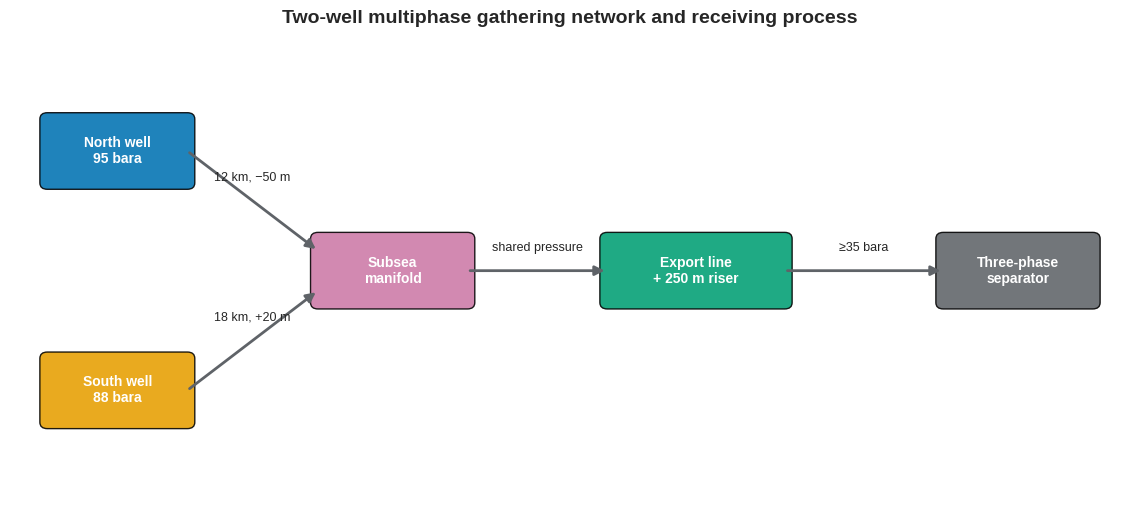

In [4]:
figure, axis = plt.subplots(figsize=(11.5, 5.3))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 6.0)
axis.axis("off")

nodes = [
    (0.4, 4.1, 1.5, 0.8, "North well\n95 bara", COLORS["blue"]),
    (0.4, 1.1, 1.5, 0.8, "South well\n88 bara", COLORS["orange"]),
    (3.3, 2.6, 1.6, 0.8, "Subsea\nmanifold", COLORS["purple"]),
    (6.4, 2.6, 1.9, 0.8, "Export line\n+ 250 m riser", COLORS["green"]),
    (10.0, 2.6, 1.6, 0.8, "Three-phase\nseparator", COLORS["grey"]),
]

for x_pos, y_pos, width, height, label, color in nodes:
    patch = FancyBboxPatch(
        (x_pos, y_pos),
        width,
        height,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="black",
        alpha=0.88,
    )
    axis.add_patch(patch)
    axis.text(
        x_pos + width / 2.0,
        y_pos + height / 2.0,
        label,
        ha="center",
        va="center",
        color="white",
        weight="bold",
    )

connections = [
    ((1.9, 4.5), (3.3, 3.25), "12 km, −50 m"),
    ((1.9, 1.5), (3.3, 2.75), "18 km, +20 m"),
    ((4.9, 3.0), (6.4, 3.0), "shared pressure"),
    ((8.3, 3.0), (10.0, 3.0), "≥35 bara"),
]

for start, end, label in connections:
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="-|>",
        mutation_scale=14,
        linewidth=2.0,
        color=COLORS["grey"],
    )
    axis.add_patch(arrow)
    label_x = 0.5 * (start[0] + end[0])
    label_y = 0.5 * (start[1] + end[1])
    axis.text(
        label_x,
        label_y + 0.25,
        label,
        ha="center",
        fontsize=9,
    )

axis.set_title(
    "Two-well multiphase gathering network and receiving process",
    fontsize=14,
    weight="bold",
)
figure.tight_layout()

The diagram shows the object and pressure topology. Each upstream branch is solved against
the same manifold pressure. Only then are its stream objects mixed and passed to the
export line and receiving separator.

## 3. Governing relationships

Beggs–Brill represents the steady one-dimensional pressure change as friction,
hydrostatic, and acceleration contributions:

$$
\Delta p = \Delta p_f + \Delta p_h + \Delta p_a
$$

A useful hydrostatic sign check is:

$$
\Delta p_h = \rho_m g \Delta z
$$

Here $\Delta p$ and its components are in Pa, $\rho_m$ is mixture density in kg/m³,
$g$ is gravitational acceleration in m/s², and $\Delta z$ is outlet minus inlet elevation
in m. A positive rise increases required pressure; a descent can recover pressure.

The no-slip input liquid fraction is:

$$
\lambda_L = \frac{v_{SL}}{v_{SL} + v_{SG}}
$$

$v_{SL}$ and $v_{SG}$ are superficial liquid and gas velocities in m/s. Beggs–Brill
correlates the actual liquid holdup $H_L$ from $\lambda_L$, Froude number, flow regime,
and inclination. Physically, $0 \le H_L \le 1$.

At the manifold and separator, total mass conservation requires:

$$
\dot m_N + \dot m_S = \dot m_{export}
$$

and:

$$
\dot m_{feed} = \dot m_{gas} + \dot m_{oil} + \dot m_{water}
$$

Every mass rate is in kg/s.

### Model choice, solver workflow, and validity

SRK with the classic mixing rule is selected for a transparent hydrocarbon production
example. `setMultiPhaseCheck(True)` allows gas, hydrocarbon liquid, and aqueous phases.
This compact fluid is appropriate for teaching network composition and hydraulics, but a
project model should use fitted heavy-end characterization and a validated water model.

`PipeBeggsAndBrills` discretizes each route, flashes the fluid as pressure and temperature
change, and returns the engineering profiles used here. The branch capacity solver varies
mass flow while preserving each well's composition, pressure, and temperature. It uses a
bounded bisection around fixed-flow pipe runs so invalid negative-pressure trials are
treated as above-capacity points. This avoids hidden state and prevents an optimizer from
publishing an unphysical pipe solution.

In [5]:
def build_well_fluid(
    well_name,
    flow_kg_s,
):
    spec = WELL_SPECS[well_name]
    system = fluid("srk")

    for component_name, mole_fraction in (
        WELL_COMPOSITIONS[well_name].items()
    ):
        system.addComponent(
            component_name,
            mole_fraction,
        )

    system.setMixingRule("classic")
    system.setMultiPhaseCheck(True)
    system.setPressure(spec["pressure_bara"], "bara")
    system.setTemperature(spec["temperature_c"], "C")
    system.setTotalFlowRate(flow_kg_s, "kg/sec")
    TPflash(system)
    system.initProperties()
    return system

In [6]:
phase_records = []

for well_name in WELL_SPECS:
    well_fluid = build_well_fluid(
        well_name,
        flow_kg_s=20.0,
    )

    for phase_index in range(well_fluid.getNumberOfPhases()):
        phase = well_fluid.getPhase(phase_index)
        phase_records.append(
            {
                "well": well_name,
                "phase": str(phase.getPhaseTypeName()),
                "phase fraction (-)": phase.getBeta(),
                "density (kg/m³)": phase.getDensity("kg/m3"),
            }
        )

phase_table = pd.DataFrame(phase_records)
display(phase_table.round(6))

,well,phase,phase fraction (-),density (kg/m³)
0,North,gas,0.646133,88.383244
1,North,oil,0.331690,515.997567
2,North,aqueous,0.022177,964.875734
3,South,gas,0.758440,80.516654
4,South,oil,0.228786,525.821501
5,South,aqueous,0.012774,971.796442


Both synthetic inlets contain gas, oil, and aqueous phases. The north well is richer and
has a larger hydrocarbon-liquid fraction. This difference is preserved when the capacity
solver changes total flow.

## 4. One reusable branch calculation

Each evaluation creates a new thermodynamic system, stream, and pipe. The branch is
isothermal to isolate hydraulic effects during optimization. The export line later
demonstrates non-isothermal heat transfer.

In [7]:
def run_branch(
    well_name,
    flow_kg_s,
    diameter_m=None,
    elevation_m=None,
    number_of_increments=20,
):
    spec = WELL_SPECS[well_name]
    branch_fluid = build_well_fluid(
        well_name,
        flow_kg_s,
    )
    inlet_stream = jneqsim.process.equipment.stream.Stream(
        f"{well_name} inlet",
        branch_fluid,
    )
    inlet_stream.run()

    pipe_class = (
        jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
    )
    branch_pipe = pipe_class(
        f"{well_name} branch",
        inlet_stream,
    )
    branch_pipe.setDiameter(
        diameter_m or spec["diameter_m"]
    )
    branch_pipe.setLength(spec["length_km"] * 1000.0)
    branch_pipe.setElevation(
        spec["elevation_m"]
        if elevation_m is None
        else elevation_m
    )
    branch_pipe.setNumberOfIncrements(number_of_increments)
    branch_pipe.setPipeWallRoughness(PIPE_ROUGHNESS_M)
    branch_pipe.setRunIsothermal(True)
    branch_pipe.run()

    length_m = [
        float(value)
        for value in branch_pipe.getLengthProfile()
    ]
    pressure_bara = [
        float(value)
        for value in branch_pipe.getPressureProfileList()
    ]
    temperature_c = [
        float(value) - 273.15
        for value in branch_pipe.getTemperatureProfileList()
    ]
    liquid_holdup = [
        float(value)
        for value in branch_pipe.getLiquidHoldupProfileList()
    ]

    return {
        "pipe": branch_pipe,
        "inlet": inlet_stream,
        "outlet": branch_pipe.getOutletStream(),
        "flow_kg_s": branch_pipe.getOutletStream().getFlowRate(
            "kg/sec"
        ),
        "outlet_pressure_bara": (
            branch_pipe.getOutletStream().getPressure("bara")
        ),
        "flow_regime": str(branch_pipe.getFlowRegime()),
        "mixture_velocity_m_s": branch_pipe.getMixtureVelocity(),
        "length_m": length_m,
        "pressure_bara": pressure_bara,
        "temperature_c": temperature_c,
        "liquid_holdup": liquid_holdup,
        "mean_holdup": float(np.mean(liquid_holdup)),
    }

In [8]:
reference_branches = {
    well_name: run_branch(
        well_name,
        flow_kg_s=20.0,
    )
    for well_name in WELL_SPECS
}
horizontal_counterfactuals = {
    well_name: run_branch(
        well_name,
        flow_kg_s=20.0,
        elevation_m=0.0,
    )
    for well_name in WELL_SPECS
}

reference_summary = pd.DataFrame(
    [
        {
            "well": well_name,
            "flow (kg/s)": result["flow_kg_s"],
            "inlet pressure (bara)": (
                result["inlet"].getPressure("bara")
            ),
            "outlet pressure (bara)": (
                result["outlet_pressure_bara"]
            ),
            "pressure change (bar)": (
                result["outlet_pressure_bara"]
                - result["inlet"].getPressure("bara")
            ),
            "mean holdup (-)": result["mean_holdup"],
            "mixture velocity (m/s)": (
                result["mixture_velocity_m_s"]
            ),
            "flow regime": result["flow_regime"],
        }
        for well_name, result in reference_branches.items()
    ]
)

display(reference_summary.round(6))

,well,flow (kg/s),inlet pressure (bara),outlet pressure (bara),pressure change (bar),mean holdup (-),mixture velocity (m/s),flow regime
0,North,20.0,95.0,81.134879,-13.865121,0.312072,4.320120,INTERMITTENT
1,South,20.0,88.0,78.682409,-9.317591,0.245597,3.413105,INTERMITTENT


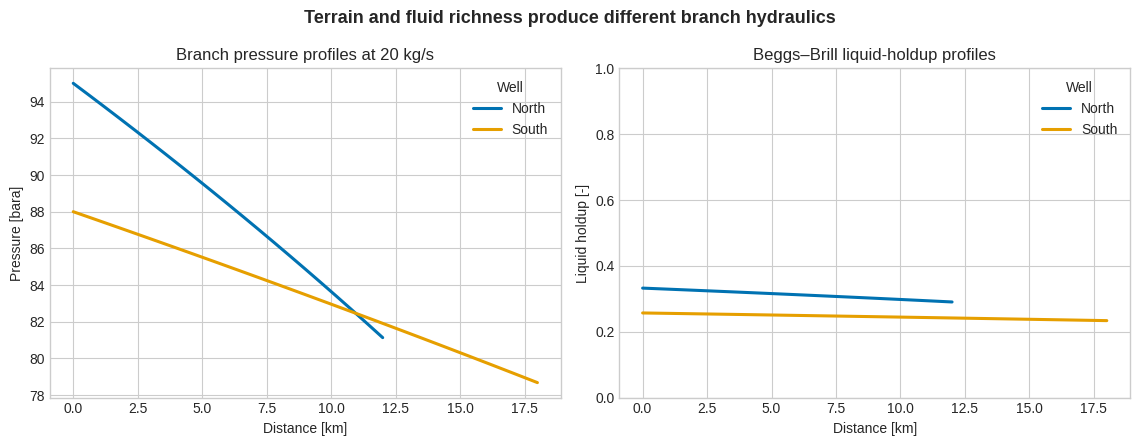

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

for well_name, color in [
    ("North", COLORS["blue"]),
    ("South", COLORS["orange"]),
]:
    result = reference_branches[well_name]
    distance_km = np.asarray(result["length_m"]) / 1000.0
    axes[0].plot(
        distance_km,
        result["pressure_bara"],
        linewidth=2.2,
        label=well_name,
        color=color,
    )
    axes[1].plot(
        distance_km,
        result["liquid_holdup"],
        linewidth=2.2,
        label=well_name,
        color=color,
    )

axes[0].set_title("Branch pressure profiles at 20 kg/s")
axes[0].set_xlabel("Distance [km]")
axes[0].set_ylabel("Pressure [bara]")
axes[0].legend(title="Well")

axes[1].set_title("Beggs–Brill liquid-holdup profiles")
axes[1].set_xlabel("Distance [km]")
axes[1].set_ylabel("Liquid holdup [-]")
axes[1].set_ylim(0.0, 1.0)
axes[1].legend(title="Well")

figure.suptitle(
    "Terrain and fluid richness produce different branch hydraulics",
    fontsize=13,
    weight="bold",
)
figure.tight_layout()

The north descent partly offsets friction, while the south rise adds hydrostatic loss.
Both holdup profiles remain bounded. The richer north fluid retains more liquid, so equal
mass flow does not imply equal hydraulic behavior.

## 5. Capacity at a shared manifold pressure

Capacity is the largest flow whose calculated branch outlet pressure remains at the
specified manifold pressure. The fixed-flow residual is:

$$
r_m = p_{out} - p_{manifold}
$$

The bounded bisection seeks $r_m = 0$. If a high-flow trial would drive pressure negative,
it is safely classified as above capacity and never returned as a solution.

In [10]:
def solve_branch_capacity(
    well_name,
    manifold_pressure_bara,
    diameter_m=None,
    iterations=14,
):
    lower_flow_kg_s = 0.05
    upper_flow_kg_s = 150.0
    last_valid_result = run_branch(
        well_name,
        lower_flow_kg_s,
        diameter_m,
    )

    for _ in range(iterations):
        trial_flow_kg_s = 0.5 * (
            lower_flow_kg_s + upper_flow_kg_s
        )

        try:
            trial_result = run_branch(
                well_name,
                trial_flow_kg_s,
                diameter_m,
            )
            outlet_pressure_bara = trial_result[
                "outlet_pressure_bara"
            ]
            last_valid_result = trial_result
        except Exception:
            outlet_pressure_bara = -1.0

        if outlet_pressure_bara > manifold_pressure_bara:
            lower_flow_kg_s = trial_flow_kg_s
        else:
            upper_flow_kg_s = trial_flow_kg_s

    capacity_result = run_branch(
        well_name,
        lower_flow_kg_s,
        diameter_m,
    )
    capacity_result["capacity_residual_bar"] = (
        capacity_result["outlet_pressure_bara"]
        - manifold_pressure_bara
    )
    return capacity_result

In [11]:
BASE_MANIFOLD_PRESSURE_BARA = 50.0
base_capacities = {
    well_name: solve_branch_capacity(
        well_name,
        BASE_MANIFOLD_PRESSURE_BARA,
    )
    for well_name in WELL_SPECS
}

capacity_summary = pd.DataFrame(
    [
        {
            "well": well_name,
            "capacity (kg/s)": result["flow_kg_s"],
            "outlet pressure (bara)": (
                result["outlet_pressure_bara"]
            ),
            "residual (bar)": result["capacity_residual_bar"],
            "mean holdup (-)": result["mean_holdup"],
            "velocity (m/s)": (
                result["mixture_velocity_m_s"]
            ),
            "flow regime": result["flow_regime"],
        }
        for well_name, result in base_capacities.items()
    ]
)

display(capacity_summary.round(6))

,well,capacity (kg/s),outlet pressure (bara),residual (bar),mean holdup (-),velocity (m/s),flow regime
0,North,31.716687,50.012658,0.012658,0.268185,11.792521,INTERMITTENT
1,South,37.189716,50.019997,0.019997,0.209247,10.561972,INTERMITTENT


The two capacities differ because well pressure, fluid composition, route length,
elevation, and diameter all differ. The residual is explicitly reported so numerical
convergence is visible rather than implied.

## 6. Manifold-pressure and export-diameter screen

Lowering manifold pressure increases branch capacity but leaves less pressure for the
export line. Raising it does the opposite. The export model combines both wellstreams,
applies a 6 °C environment through an overall heat-transfer coefficient of
5 W/(m²·K), and includes the 250 m net rise.

In [12]:
def run_export_system(
    north_result,
    south_result,
    export_diameter_m,
    number_of_increments=50,
):
    manifold = jneqsim.process.equipment.mixer.Mixer(
        "Subsea manifold"
    )
    manifold.addStream(north_result["outlet"])
    manifold.addStream(south_result["outlet"])
    manifold.run()

    pipe_class = (
        jneqsim.process.equipment.pipeline.PipeBeggsAndBrills
    )
    export_pipe = pipe_class(
        "Export flowline and riser",
        manifold.getOutletStream(),
    )
    export_pipe.setDiameter(export_diameter_m)
    export_pipe.setLength(EXPORT_LENGTH_M)
    export_pipe.setElevation(EXPORT_ELEVATION_M)
    export_pipe.setNumberOfIncrements(number_of_increments)
    export_pipe.setPipeWallRoughness(PIPE_ROUGHNESS_M)
    export_pipe.setConstantSurfaceTemperature(
        AMBIENT_TEMPERATURE_C,
        "C",
    )
    export_pipe.setHeatTransferCoefficient(
        OVERALL_HEAT_TRANSFER_W_M2_K
    )
    export_pipe.run()

    pressure_profile = [
        float(value)
        for value in export_pipe.getPressureProfileList()
    ]
    temperature_profile_c = [
        float(value) - 273.15
        for value in export_pipe.getTemperatureProfileList()
    ]
    liquid_holdup_profile = [
        float(value)
        for value in export_pipe.getLiquidHoldupProfileList()
    ]

    return {
        "mixer": manifold,
        "pipe": export_pipe,
        "outlet": export_pipe.getOutletStream(),
        "flow_kg_s": (
            manifold.getOutletStream().getFlowRate("kg/sec")
        ),
        "outlet_pressure_bara": (
            export_pipe.getOutletStream().getPressure("bara")
        ),
        "outlet_temperature_c": (
            export_pipe.getOutletStream().getTemperature("C")
        ),
        "mixture_velocity_m_s": export_pipe.getMixtureVelocity(),
        "flow_regime": str(export_pipe.getFlowRegime()),
        "mean_holdup": float(
            np.mean(liquid_holdup_profile)
        ),
        "length_km": np.asarray(
            export_pipe.getLengthProfile(),
            dtype=float,
        ) / 1000.0,
        "pressure_bara": pressure_profile,
        "temperature_c": temperature_profile_c,
        "liquid_holdup": liquid_holdup_profile,
        "fiv_lof": export_pipe.calculateLOF(),
        "frms_n_m": export_pipe.calculateFRMS(),
    }

In [13]:
manifold_pressure_grid_bara = np.arange(
    44.0,
    62.1,
    2.0,
)
screen_records = []
screen_cache = {}

for manifold_pressure_bara in manifold_pressure_grid_bara:
    north_result = solve_branch_capacity(
        "North",
        manifold_pressure_bara,
    )
    south_result = solve_branch_capacity(
        "South",
        manifold_pressure_bara,
    )
    screen_cache[manifold_pressure_bara] = {
        "North": north_result,
        "South": south_result,
    }

    for export_diameter_m in EXPORT_DIAMETERS_M:
        try:
            export_result = run_export_system(
                north_result,
                south_result,
                export_diameter_m,
            )
            screen_records.append(
                {
                    "manifold pressure (bara)": (
                        manifold_pressure_bara
                    ),
                    "export diameter (m)": export_diameter_m,
                    "north flow (kg/s)": (
                        north_result["flow_kg_s"]
                    ),
                    "south flow (kg/s)": (
                        south_result["flow_kg_s"]
                    ),
                    "total flow (kg/s)": (
                        export_result["flow_kg_s"]
                    ),
                    "delivery pressure (bara)": (
                        export_result["outlet_pressure_bara"]
                    ),
                    "export velocity (m/s)": (
                        export_result["mixture_velocity_m_s"]
                    ),
                    "export holdup (-)": (
                        export_result["mean_holdup"]
                    ),
                    "FIV LOF (-)": export_result["fiv_lof"],
                }
            )
        except Exception:
            screen_records.append(
                {
                    "manifold pressure (bara)": (
                        manifold_pressure_bara
                    ),
                    "export diameter (m)": export_diameter_m,
                    "north flow (kg/s)": (
                        north_result["flow_kg_s"]
                    ),
                    "south flow (kg/s)": (
                        south_result["flow_kg_s"]
                    ),
                    "total flow (kg/s)": (
                        north_result["flow_kg_s"]
                        + south_result["flow_kg_s"]
                    ),
                    "delivery pressure (bara)": np.nan,
                    "export velocity (m/s)": np.nan,
                    "export holdup (-)": np.nan,
                    "FIV LOF (-)": np.nan,
                }
            )

screen_table = pd.DataFrame(screen_records)
display(screen_table.round(5))

,manifold pressure (bara),export diameter (m),north flow (kg/s),south flow (kg/s),total flow (kg/s),delivery pressure (bara),export velocity (m/s),export holdup (-),FIV LOF (-)
0,44.0,0.4572,32.99800,39.13914,72.13714,23.41035,11.24859,0.14728,0.13126
1,44.0,0.5080,32.99800,39.13914,72.13714,31.86818,6.49724,0.17234,0.06602
2,44.0,0.5588,32.99800,39.13914,72.13714,35.26189,4.76459,0.20810,0.04428
3,46.0,0.4572,32.59530,38.52594,71.12124,27.28391,9.39188,0.15654,0.11437
4,46.0,0.5080,32.59530,38.52594,71.12124,34.53020,5.85141,0.18322,0.06154
5,46.0,0.5588,32.59530,38.52594,71.12124,37.66427,4.35502,0.21945,0.04142
6,48.0,0.4572,32.16515,37.87613,70.04128,30.81576,8.09025,0.16543,0.10192
7,48.0,0.5080,32.16515,37.87613,70.04128,37.10358,5.30931,0.19424,0.05751
8,48.0,0.5588,32.16515,37.87613,70.04128,40.08057,3.99122,0.23099,0.03873
9,50.0,0.4572,31.71669,37.18972,68.90640,34.06473,7.11845,0.17393,0.09208


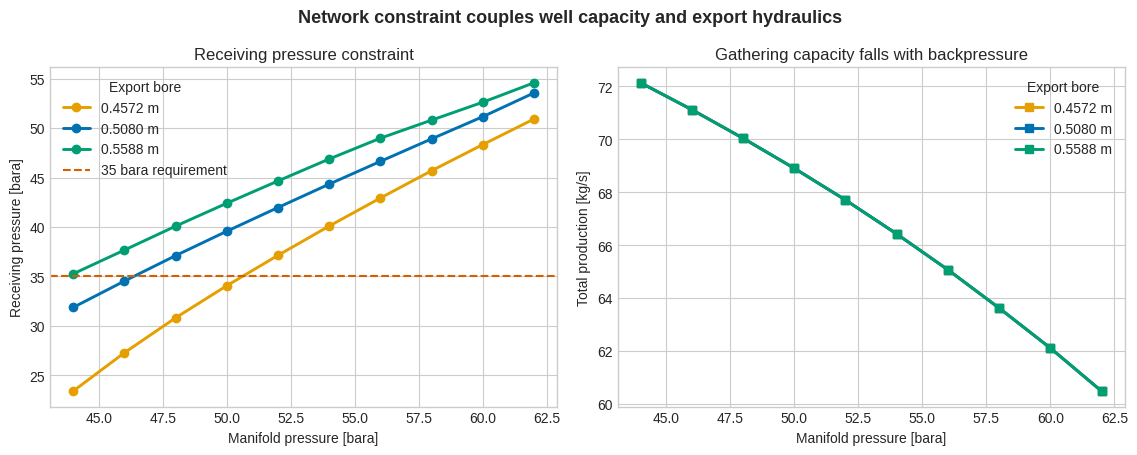

In [14]:
figure, axes = plt.subplots(1, 2, figsize=(11.5, 4.6))

for export_diameter_m, color in zip(
    EXPORT_DIAMETERS_M,
    [COLORS["orange"], COLORS["blue"], COLORS["green"]],
):
    diameter_data = screen_table[
        screen_table["export diameter (m)"]
        == export_diameter_m
    ]
    label = f"{export_diameter_m:.4f} m"
    axes[0].plot(
        diameter_data["manifold pressure (bara)"],
        diameter_data["delivery pressure (bara)"],
        marker="o",
        linewidth=2.1,
        label=label,
        color=color,
    )
    axes[1].plot(
        diameter_data["manifold pressure (bara)"],
        diameter_data["total flow (kg/s)"],
        marker="s",
        linewidth=2.1,
        label=label,
        color=color,
    )

axes[0].axhline(
    RECEIVING_PRESSURE_BARA,
    color=COLORS["red"],
    linestyle="--",
    label="35 bara requirement",
)
axes[0].set_title("Receiving pressure constraint")
axes[0].set_xlabel("Manifold pressure [bara]")
axes[0].set_ylabel("Receiving pressure [bara]")
axes[0].legend(title="Export bore")

axes[1].set_title("Gathering capacity falls with backpressure")
axes[1].set_xlabel("Manifold pressure [bara]")
axes[1].set_ylabel("Total production [kg/s]")
axes[1].legend(title="Export bore")

figure.suptitle(
    "Network constraint couples well capacity and export hydraulics",
    fontsize=13,
    weight="bold",
)
figure.tight_layout()

A larger export bore reaches 35 bara at a lower manifold pressure and therefore permits
more production. The production curves coincide for a given manifold pressure because the
upstream branches are unchanged; the diameter acts through the downstream constraint.

## 7. Discrete design selection

For each diameter, the feasible grid case with the highest production is retained.
A transparent pipe-size index $I_D = L D^2$ is reported in km·m². It is not CAPEX.
The selected design is the smallest export bore whose feasible grid capacity exceeds
65 kg/s, velocity is below 8 m/s, and FIV likelihood-of-failure indicator is below 0.6.
These are educational screening constraints, not project acceptance criteria.

In [15]:
feasible_screen = screen_table[
    (screen_table["delivery pressure (bara)"]
     >= RECEIVING_PRESSURE_BARA)
    & (screen_table["export velocity (m/s)"] < 8.0)
    & (screen_table["FIV LOF (-)"] < 0.6)
].copy()

diameter_candidates = (
    feasible_screen.sort_values(
        [
            "export diameter (m)",
            "total flow (kg/s)",
        ],
        ascending=[True, False],
    )
    .groupby("export diameter (m)", as_index=False)
    .first()
)
diameter_candidates["pipe-size index (km m²)"] = (
    EXPORT_LENGTH_M
    / 1000.0
    * diameter_candidates["export diameter (m)"] ** 2
)
diameter_candidates["capacity target met"] = (
    diameter_candidates["total flow (kg/s)"] >= 65.0
)

eligible_candidates = diameter_candidates[
    diameter_candidates["capacity target met"]
]
selected_grid_case = eligible_candidates.sort_values(
    "export diameter (m)"
).iloc[0]

display(diameter_candidates.round(6))

,export diameter (m),manifold pressure (bara),north flow (kg/s),south flow (kg/s),total flow (kg/s),delivery pressure (bara),export velocity (m/s),export holdup (-),FIV LOF (-),pipe-size index (km m²),capacity target met
0,0.4572,52.0,31.240771,36.466690,67.707462,37.133738,6.346634,0.182231,0.083783,5.225796,True
1,0.5080,48.0,32.165146,37.876132,70.041278,37.103582,5.309310,0.194235,0.057512,6.451600,True
2,0.5588,44.0,32.997998,39.139139,72.137137,35.261888,4.764590,0.208102,0.044285,7.806436,True


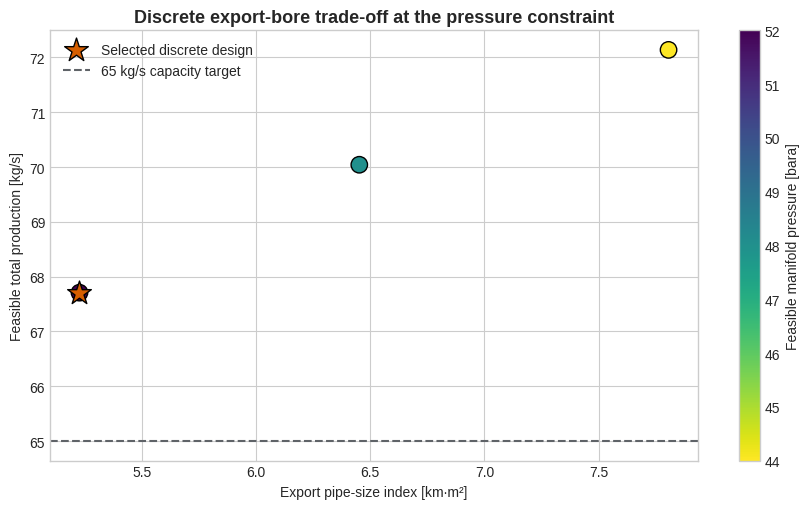

In [16]:
figure, axis = plt.subplots(figsize=(8.8, 5.2))
scatter = axis.scatter(
    diameter_candidates["pipe-size index (km m²)"],
    diameter_candidates["total flow (kg/s)"],
    c=diameter_candidates["manifold pressure (bara)"],
    cmap="viridis_r",
    s=140,
    edgecolor="black",
)
axis.scatter(
    selected_grid_case["pipe-size index (km m²)"],
    selected_grid_case["total flow (kg/s)"],
    marker="*",
    s=320,
    color=COLORS["red"],
    edgecolor="black",
    label="Selected discrete design",
    zorder=4,
)
colorbar = figure.colorbar(scatter, ax=axis)
colorbar.set_label("Feasible manifold pressure [bara]")
axis.axhline(
    65.0,
    color=COLORS["grey"],
    linestyle="--",
    label="65 kg/s capacity target",
)
axis.set_xlabel("Export pipe-size index [km·m²]")
axis.set_ylabel("Feasible total production [kg/s]")
axis.set_title(
    "Discrete export-bore trade-off at the pressure constraint",
    fontsize=13,
    weight="bold",
)
axis.legend()
figure.tight_layout()

The star is the smallest bore satisfying all stated screen constraints. A real
optimization would combine well inflow performance, availability, slugging, erosion,
terrain, insulation, wall thickness, installation cost, compression, and uncertainty.

## 8. Refine the selected operating point

The grid is useful for visualization but not for a final pressure result. A second
bisection refines the manifold pressure for the selected diameter until the calculated
receiving pressure is close to 35 bara.

In [17]:
def solve_network_manifold_pressure(
    export_diameter_m,
    lower_pressure_bara=44.0,
    upper_pressure_bara=62.0,
    iterations=10,
):
    accepted = None

    for _ in range(iterations):
        trial_pressure_bara = 0.5 * (
            lower_pressure_bara + upper_pressure_bara
        )
        north_result = solve_branch_capacity(
            "North",
            trial_pressure_bara,
        )
        south_result = solve_branch_capacity(
            "South",
            trial_pressure_bara,
        )

        try:
            export_result = run_export_system(
                north_result,
                south_result,
                export_diameter_m,
            )
            delivery_pressure_bara = export_result[
                "outlet_pressure_bara"
            ]
            accepted = {
                "manifold_pressure_bara": (
                    trial_pressure_bara
                ),
                "north": north_result,
                "south": south_result,
                "export": export_result,
            }
        except Exception:
            delivery_pressure_bara = -1.0

        if delivery_pressure_bara < RECEIVING_PRESSURE_BARA:
            lower_pressure_bara = trial_pressure_bara
        else:
            upper_pressure_bara = trial_pressure_bara

    return accepted


selected_export_diameter_m = float(
    selected_grid_case["export diameter (m)"]
)
selected_network = solve_network_manifold_pressure(
    selected_export_diameter_m
)

selected_summary = pd.DataFrame(
    {
        "quantity": [
            "Export diameter",
            "Manifold pressure",
            "North capacity",
            "South capacity",
            "Total production",
            "Receiving pressure",
            "Receiving temperature",
            "Export velocity",
            "Mean export holdup",
            "Export FIV LOF",
        ],
        "value": [
            selected_export_diameter_m,
            selected_network["manifold_pressure_bara"],
            selected_network["north"]["flow_kg_s"],
            selected_network["south"]["flow_kg_s"],
            selected_network["export"]["flow_kg_s"],
            selected_network["export"][
                "outlet_pressure_bara"
            ],
            selected_network["export"][
                "outlet_temperature_c"
            ],
            selected_network["export"][
                "mixture_velocity_m_s"
            ],
            selected_network["export"]["mean_holdup"],
            selected_network["export"]["fiv_lof"],
        ],
        "unit": [
            "m",
            "bara",
            "kg/s",
            "kg/s",
            "kg/s",
            "bara",
            "°C",
            "m/s",
            "-",
            "-",
        ],
    }
)

display(selected_summary.round(7))

,quantity,value,unit
0,Export diameter,0.457200,m
1,Manifold pressure,50.591797,bara
2,North capacity,31.579404,kg/s
3,South capacity,36.979214,kg/s
4,Total production,68.558618,kg/s
5,Receiving pressure,34.987839,bara
6,Receiving temperature,26.571165,°C
7,Export velocity,6.873101,m/s
8,Mean export holdup,0.176404,-
9,Export FIV LOF,0.089492,-


## 9. Final application: connected NeqSim process and separation

The practical application reuses the accepted branch objects, adds their inlets, pipes,
manifold, export pipe, and a native `ThreePhaseSeparator` to one `ProcessSystem`, and runs
them in flow order. This demonstrates how thermodynamic systems become streams, streams
connect unit operations, and results propagate to gas, oil, and water products.

In [18]:
final_separator = (
    jneqsim.process.equipment.separator.ThreePhaseSeparator(
        "Receiving three-phase separator",
        selected_network["export"]["outlet"],
    )
)

final_process = jneqsim.process.processmodel.ProcessSystem()
final_process.add(selected_network["north"]["inlet"])
final_process.add(selected_network["north"]["pipe"])
final_process.add(selected_network["south"]["inlet"])
final_process.add(selected_network["south"]["pipe"])
final_process.add(selected_network["export"]["mixer"])
final_process.add(selected_network["export"]["pipe"])
final_process.add(final_separator)
final_process.run()

print(
    "Connected unit operations:",
    len(final_process.getUnitOperations()),
)

Connected unit operations: 7


In [19]:
product_streams = {
    "gas": final_separator.getGasOutStream(),
    "oil": final_separator.getOilOutStream(),
    "water": final_separator.getWaterOutStream(),
}

product_records = []

for product_name, product_stream in product_streams.items():
    product_records.append(
        {
            "product": product_name,
            "mass rate (kg/s)": product_stream.getFlowRate(
                "kg/sec"
            ),
            "temperature (°C)": product_stream.getTemperature(
                "C"
            ),
            "pressure (bara)": product_stream.getPressure(
                "bara"
            ),
        }
    )

product_table = pd.DataFrame(product_records)
feed_mass_kg_s = selected_network["export"]["outlet"].getFlowRate(
    "kg/sec"
)
product_mass_kg_s = product_table["mass rate (kg/s)"].sum()
mass_residual_kg_s = product_mass_kg_s - feed_mass_kg_s

display(product_table.round(7))
print(f"Separator feed: {feed_mass_kg_s:.7f} kg/s")
print(f"Product total: {product_mass_kg_s:.7f} kg/s")
print(f"Mass residual: {mass_residual_kg_s:.3e} kg/s")

,product,mass rate (kg/s),temperature (°C),pressure (bara)
0,gas,33.446522,26.571165,34.987839
1,oil,34.379248,26.571165,34.987839
2,water,0.732849,26.571165,34.987839


Separator feed: 68.5586182 kg/s
Product total: 68.5586182 kg/s
Mass residual: -4.547e-12 kg/s


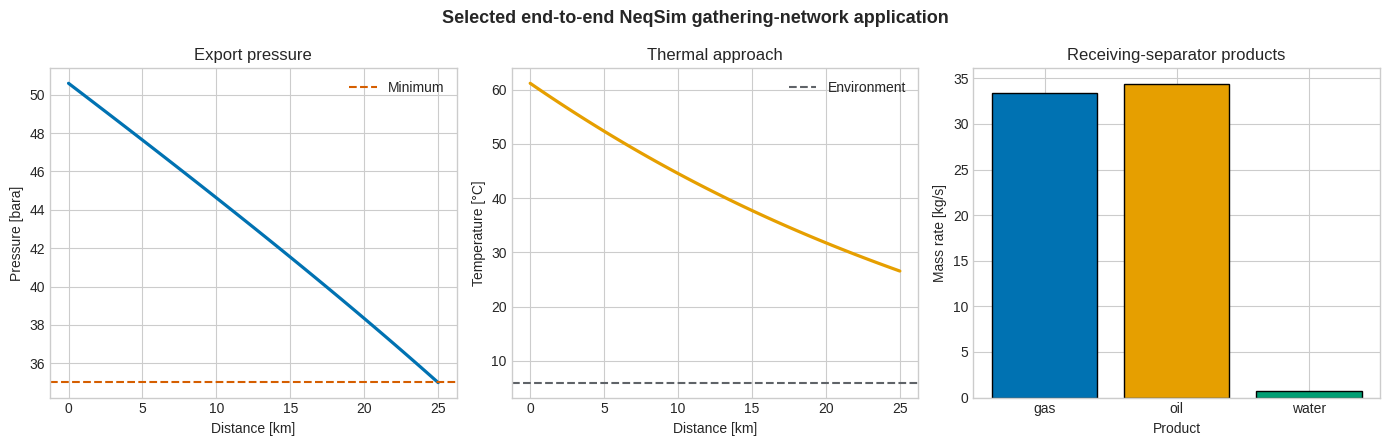

In [20]:
figure, axes = plt.subplots(1, 3, figsize=(14.0, 4.5))
export_result = selected_network["export"]

axes[0].plot(
    export_result["length_km"],
    export_result["pressure_bara"],
    color=COLORS["blue"],
    linewidth=2.3,
)
axes[0].axhline(
    RECEIVING_PRESSURE_BARA,
    color=COLORS["red"],
    linestyle="--",
    label="Minimum",
)
axes[0].set_title("Export pressure")
axes[0].set_xlabel("Distance [km]")
axes[0].set_ylabel("Pressure [bara]")
axes[0].legend()

axes[1].plot(
    export_result["length_km"],
    export_result["temperature_c"],
    color=COLORS["orange"],
    linewidth=2.3,
)
axes[1].axhline(
    AMBIENT_TEMPERATURE_C,
    color=COLORS["grey"],
    linestyle="--",
    label="Environment",
)
axes[1].set_title("Thermal approach")
axes[1].set_xlabel("Distance [km]")
axes[1].set_ylabel("Temperature [°C]")
axes[1].legend()

axes[2].bar(
    product_table["product"],
    product_table["mass rate (kg/s)"],
    color=[
        COLORS["blue"],
        COLORS["orange"],
        COLORS["green"],
    ],
    edgecolor="black",
)
axes[2].set_title("Receiving-separator products")
axes[2].set_xlabel("Product")
axes[2].set_ylabel("Mass rate [kg/s]")

figure.suptitle(
    "Selected end-to-end NeqSim gathering-network application",
    fontsize=13,
    weight="bold",
)
figure.tight_layout()

Pressure declines smoothly to the receiving constraint, and the fluid cools toward the
6 °C environment without crossing it. The separator closes the total mass balance while
exposing gas, oil, and water streams for downstream processing or economics.

## 10. Verification and engineering checks

The following assertions check inputs, phase behavior, hydraulic convergence, profile
bounds, expected trends, design constraints, process connectivity, and separator mass
closure. They are deliberately scale-aware and avoid asserting undocumented benchmark
numbers.

In [21]:
check_results = {}

check_results["composition sums"] = all(
    math.isclose(
        sum(composition.values()),
        1.0,
        abs_tol=1.0e-12,
    )
    for composition in WELL_COMPOSITIONS.values()
)
check_results["three phases at both inlets"] = (
    phase_table.groupby("well").size().eq(3).all()
)
check_results["positive phase densities"] = (
    phase_table["density (kg/m³)"].gt(0.0).all()
)
check_results["reference pressures finite"] = np.isfinite(
    reference_summary["outlet pressure (bara)"]
).all()
check_results["reference holdup bounded"] = (
    reference_summary["mean holdup (-)"]
    .between(0.0, 1.0)
    .all()
)
check_results["north descent helps pressure"] = (
    reference_branches["North"]["outlet_pressure_bara"]
    > horizontal_counterfactuals["North"][
        "outlet_pressure_bara"
    ]
)
check_results["south rise costs pressure"] = (
    reference_branches["South"]["outlet_pressure_bara"]
    < horizontal_counterfactuals["South"][
        "outlet_pressure_bara"
    ]
)
check_results["capacity residuals small"] = (
    capacity_summary["residual (bar)"].abs().max() < 0.25
)
check_results["capacity holdup bounded"] = (
    capacity_summary["mean holdup (-)"]
    .between(0.0, 1.0)
    .all()
)
check_results["capacity velocities positive"] = (
    capacity_summary["velocity (m/s)"].gt(0.0).all()
)
check_results["screen contains finite cases"] = (
    screen_table["delivery pressure (bara)"].notna().sum() >= 20
)

for export_diameter_m in EXPORT_DIAMETERS_M:
    diameter_data = screen_table[
        screen_table["export diameter (m)"]
        == export_diameter_m
    ].sort_values("manifold pressure (bara)")
    check_results[
        f"delivery pressure rises for {export_diameter_m:.4f} m"
    ] = (
        diameter_data["delivery pressure (bara)"]
        .dropna()
        .diff()
        .dropna()
        .gt(0.0)
        .all()
    )
    check_results[
        f"production falls for {export_diameter_m:.4f} m"
    ] = (
        diameter_data["total flow (kg/s)"]
        .diff()
        .dropna()
        .lt(0.0)
        .all()
    )

check_results["eligible design found"] = (
    not eligible_candidates.empty
)
check_results["selected capacity target"] = (
    selected_network["export"]["flow_kg_s"] >= 65.0
)
check_results["selected delivery pressure"] = (
    abs(
        selected_network["export"]["outlet_pressure_bara"]
        - RECEIVING_PRESSURE_BARA
    )
    < 0.15
)
check_results["selected export velocity"] = (
    0.0
    < selected_network["export"]["mixture_velocity_m_s"]
    < 8.0
)
check_results["selected FIV LOF"] = (
    0.0 <= selected_network["export"]["fiv_lof"] < 0.6
)
check_results["selected export holdup"] = (
    0.0 < selected_network["export"]["mean_holdup"] < 1.0
)
check_results["pressure profile finite"] = np.isfinite(
    selected_network["export"]["pressure_bara"]
).all()
check_results["pressure profile positive"] = (
    np.asarray(
        selected_network["export"]["pressure_bara"]
    )
    .min()
    > 0.0
)
check_results["temperature profile finite"] = np.isfinite(
    selected_network["export"]["temperature_c"]
).all()
check_results["thermal direction physical"] = (
    selected_network["export"]["temperature_c"][-1]
    < selected_network["export"]["temperature_c"][0]
)
check_results["temperature above environment"] = (
    np.asarray(
        selected_network["export"]["temperature_c"]
    )
    .min()
    >= AMBIENT_TEMPERATURE_C - 0.1
)
check_results["seven connected units"] = (
    len(final_process.getUnitOperations()) == 7
)
check_results["three separator products"] = (
    set(product_table["product"]) == {"gas", "oil", "water"}
)
check_results["positive product rates"] = (
    product_table["mass rate (kg/s)"].gt(0.0).all()
)
check_results["separator mass closure"] = (
    abs(mass_residual_kg_s)
    < max(1.0e-8, 1.0e-8 * feed_mass_kg_s)
)

failed_checks = [
    name
    for name, passed in check_results.items()
    if not bool(passed)
]
assert not failed_checks, failed_checks

print(
    f"All {len(check_results)} engineering checks passed."
)

All 32 engineering checks passed.


## Troubleshooting

- **Negative-pressure exception:** the requested flow exceeds the current pipe/pressure
  bracket. Lower the upper flow bound, increase well pressure or diameter, or raise the
  manifold-pressure bracket. Do not accept the failed trial as a capacity.
- **No oil or water product:** check that `setMultiPhaseCheck(True)` is called and that the
  selected pressure and temperature actually form the intended phases.
- **Unequal manifold pressures:** solve each branch against the same target and inspect
  `capacity_residual_bar` before mixing.
- **Slow scenario study:** reduce the grid first, then refine only the accepted design.
  Always create fresh mutable NeqSim objects for independent optimization trials.
- **Different result after changing composition:** re-run every cell from the fluid
  definitions; cached streams must not be reused across incompatible cases.

## Limitations and applicability

This is a steady screening model. Beggs–Brill is empirical and carries model-form
uncertainty, especially for terrain-induced slugging, large diameters, and compositions
outside its validation range. The capacity calculation does not include reservoir inflow
performance, wellbore lift, choke curves, transient line pack, severe slugging, restart,
wax, hydrate, scale, corrosion, fittings, availability, or control-system response.

The FIV indicator is a screening metric, not a mechanical integrity assessment. A project
design requires surveyed terrain, calibrated heat transfer, representative fluids,
uncertainty cases, mechanical code checks, transient simulation, and operating data.

## Summary and further exercises

- NeqSim represented two distinct three-phase fluids and their changing properties.
- Two `PipeBeggsAndBrills` branches were capacity-balanced at one manifold pressure.
- Manifold pressure coupled upstream production to export delivery pressure.
- A discrete bore screen selected the smallest alternative meeting the stated constraints.
- `Mixer`, thermal export pipe, `ThreePhaseSeparator`, and `ProcessSystem` formed a complete
  reusable application.
- The final checks verified phase bounds, expected trends, pressure, temperature,
  connectivity, and separator mass closure.

Suggested extensions:

1. Replace the synthetic compositions with characterized public PVT data.
2. Add a third well and test one-branch-unavailable cases.
3. Compare Beggs–Brill with NeqSim's mechanistic two-fluid model.
4. Add reservoir inflow and choke equations before maximizing production.
5. Introduce surveyed elevation legs and a transient severe-slugging study.
6. Replace the pipe-size index with documented CAPEX, OPEX, and availability models.

## Authoritative references

- Beggs, H. D. and Brill, J. P. (1973), *A Study of Two-Phase Flow in Inclined
  Pipes*, Journal of Petroleum Technology, SPE-4007-PA.
- NeqSim documentation:
  [`PipeBeggsAndBrills`](https://github.com/equinor/neqsim/blob/master/docs/process/PipeBeggsAndBrills.md).
- NeqSim source:
  [`PipeBeggsAndBrills.java`](https://github.com/equinor/neqsim/blob/master/src/main/java/neqsim/process/equipment/pipeline/PipeBeggsAndBrills.java).
- NeqSim Python package:
  [`neqsim` on PyPI](https://pypi.org/project/neqsim/).
- Historical reference retained from the original placeholder:
  [GAP brochure](https://www.petex.com/media/2274/gap-brochure.pdf).